In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("UPI Fraud Analysis Started!")

UPI Fraud Analysis Started!


In [2]:
from google.colab import files

uploaded = files.upload()

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = pd.DataFrame({
    "Transaction_ID": range(1, 1001),
    "Amount": np.random.randint(100, 50000, 1000),
    "Transaction_Frequency": np.random.randint(1, 20, 1000),
    "Device_Changes": np.random.randint(0, 5, 1000),
    "Account_Age_Days": np.random.randint(10, 1500, 1000),
    "Fraud": np.random.choice([0, 1], 1000, p=[0.9, 0.1])
})

data.head()

,Transaction_ID,Amount,Transaction_Frequency,Device_Changes,Account_Age_Days,Fraud
0,1,15895,5,2,762,0
1,2,960,6,3,876,0
2,3,38258,2,1,1457,0
3,4,44832,13,2,151,0
4,5,11384,6,2,1324,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Transaction_ID         1000 non-null   int64
 1   Amount                 1000 non-null   int64
 2   Transaction_Frequency  1000 non-null   int64
 3   Device_Changes         1000 non-null   int64
 4   Account_Age_Days       1000 non-null   int64
 5   Fraud                  1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


In [5]:
data.describe()

,Transaction_ID,Amount,Transaction_Frequency,Device_Changes,Account_Age_Days,Fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,24592.139000,9.872000,2.062000,766.941000,0.095000
std,288.819436,14632.696566,5.508353,1.410725,428.116126,0.293362
min,1.000000,109.000000,1.000000,0.000000,10.000000,0.000000
25%,250.750000,11480.000000,5.000000,1.000000,405.500000,0.000000
50%,500.500000,23965.000000,10.000000,2.000000,766.500000,0.000000
75%,750.250000,37953.750000,15.000000,3.000000,1135.500000,0.000000
max,1000.000000,49950.000000,19.000000,4.000000,1499.000000,1.000000


In [6]:
fraud_percentage = data["Fraud"].mean() * 100

print("Fraud Percentage:", fraud_percentage, "%")

Fraud Percentage: 9.5 %


In [7]:
data["Fraud"].value_counts()

,count
Fraud,
0,905
1,95


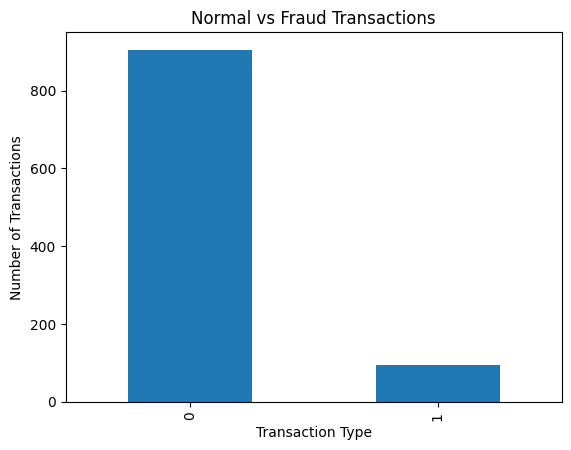

In [8]:
import matplotlib.pyplot as plt

data["Fraud"].value_counts().plot(kind="bar")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
data["Amount"].mean()

np.float64(24592.139)

In [11]:
data.groupby("Fraud")["Amount"].mean()

,Amount
Fraud,
0,24370.650829
1,26702.105263


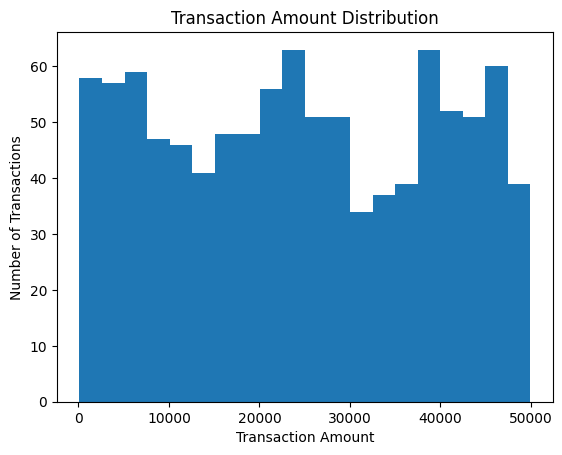

In [12]:
plt.hist(data["Amount"], bins=20)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

In [13]:
Q1 = data["Amount"].quantile(0.25)
Q3 = data["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -28230.625
Upper Limit: 77664.375


In [14]:
outliers = data[
    (data["Amount"] < lower_limit) |
    (data["Amount"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


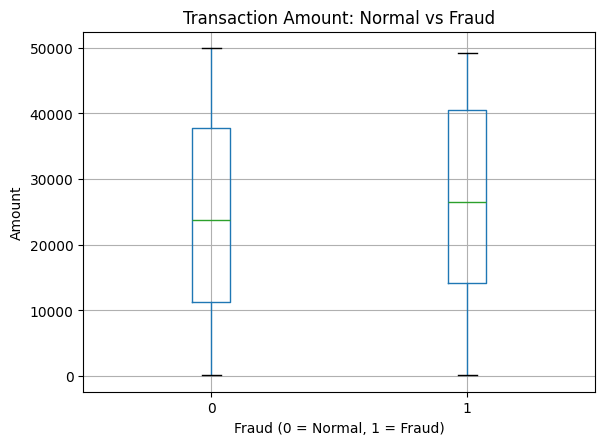

In [15]:
data.boxplot(column="Amount", by="Fraud")

plt.title("Transaction Amount: Normal vs Fraud")
plt.suptitle("")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

In [16]:
data.groupby("Fraud")["Transaction_Frequency"].mean()

,Transaction_Frequency
Fraud,
0,9.841989
1,10.157895


In [17]:
data.groupby("Fraud")["Device_Changes"].mean()

,Device_Changes
Fraud,
0,2.068508
1,2.000000


In [18]:
data.groupby("Fraud")["Account_Age_Days"].mean()

,Account_Age_Days
Fraud,
0,766.562431
1,770.547368


In [19]:
from scipy.stats import ttest_ind

normal = data[data["Fraud"] == 0]["Amount"]
fraud = data[data["Fraud"] == 1]["Amount"]

t_stat, p_value = ttest_ind(normal, fraud)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.4782440052395738
P-value: 0.13965800179893811


In [20]:
suspicious = data[
    (data["Amount"] > 40000) &
    (data["Transaction_Frequency"] > 15)
]

print("Suspicious Transactions:", len(suspicious))

Suspicious Transactions: 37


In [21]:
suspicious["Fraud"].value_counts()

,count
Fraud,
0,31
1,6


In [22]:
suspicious_fraud_percentage = (
    (suspicious["Fraud"] == 1).sum() / len(suspicious)
) * 100

print("Fraud Percentage among Suspicious Transactions:",
      suspicious_fraud_percentage, "%")

Fraud Percentage among Suspicious Transactions: 16.216216216216218 %


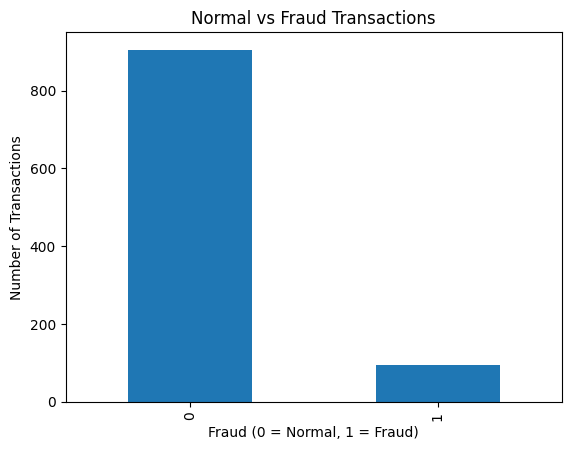

In [23]:
data["Fraud"].value_counts().plot(kind="bar")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

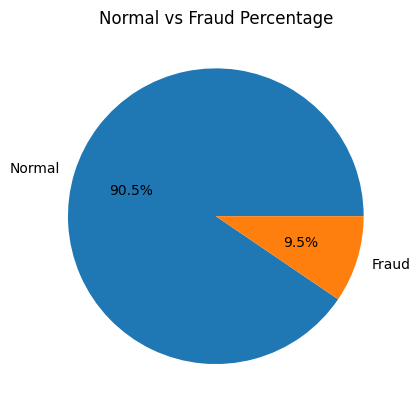

In [24]:
fraud_counts = data["Fraud"].value_counts()

plt.pie(
    fraud_counts,
    labels=["Normal", "Fraud"],
    autopct="%1.1f%%"
)

plt.title("Normal vs Fraud Percentage")
plt.show()

In [25]:
print("=== UPI FRAUD SIGNAL SUMMARY ===")
print("Total Transactions:", len(data))
print("Fraud Transactions:", (data["Fraud"] == 1).sum())
print("Fraud Percentage:", data["Fraud"].mean() * 100, "%")
print("Suspicious Transactions:", len(suspicious))
print("Fraud in Suspicious Transactions:", (suspicious["Fraud"] == 1).sum())

=== UPI FRAUD SIGNAL SUMMARY ===
Total Transactions: 1000
Fraud Transactions: 95
Fraud Percentage: 9.5 %
Suspicious Transactions: 37
Fraud in Suspicious Transactions: 6


UPI FRAUD STATISTICAL SIGNALS

1. Problem Statement

Digital payment platforms process a large number of transactions every day. Statistical analysis can help identify unusual transaction patterns that may indicate fraudulent activity.

2. Objective

The objective of this project is to analyze UPI transaction data using statistical methods and identify suspicious patterns that may indicate fraud.

3. Dataset Description

The dataset contains 1,000 UPI transaction records.

The main features used for analysis are:
- Transaction_ID
- Amount
- Transaction_Frequency
- Device_Changes
- Account_Age_Days
- Fraud

Fraud = 0 represents a normal transaction.
Fraud = 1 represents a fraudulent transaction.

4. Statistical Analysis

Descriptive statistical methods were used to understand the transaction data.

Key findings:

- Total transactions: 1,000
- Fraud transactions: 95
- Fraud percentage: 9.5%
- Average transaction amount: ₹24,592
- Average amount for normal transactions: ₹24,371
- Average amount for fraudulent transactions: ₹26,702

The analysis also used mean, frequency comparison, distribution analysis, and IQR-based outlier detection.

5. Outlier Detection

The Interquartile Range (IQR) method was used to detect unusual transaction amounts.

The calculated limits were:

Lower Limit: -28,230.625
Upper Limit: 77,664.375

The analysis found 0 outliers in the transaction amount column.

This indicates that no transaction amount was identified as an outlier using the IQR method.

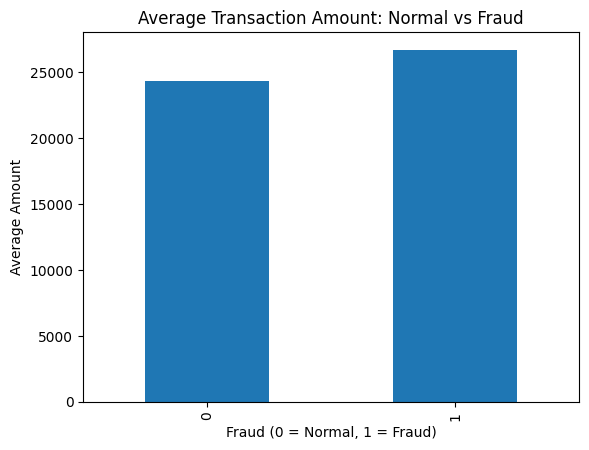

In [26]:
data.groupby("Fraud")["Amount"].mean().plot(kind="bar")

plt.title("Average Transaction Amount: Normal vs Fraud")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Amount")
plt.show()

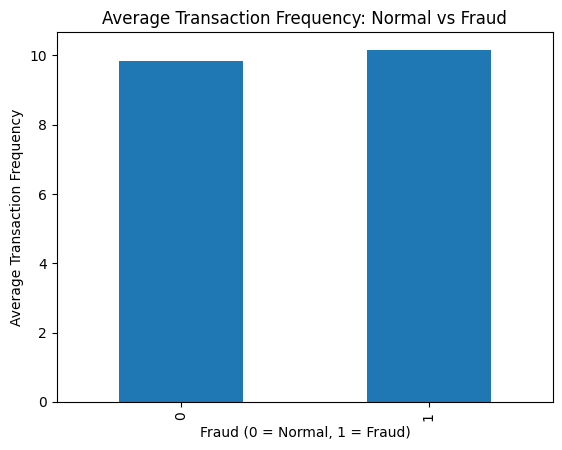

In [27]:
data.groupby("Fraud")["Transaction_Frequency"].mean().plot(kind="bar")

plt.title("Average Transaction Frequency: Normal vs Fraud")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Transaction Frequency")
plt.show()

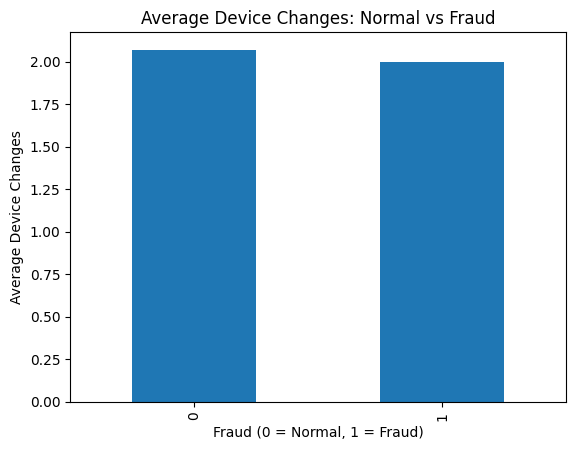

In [28]:
data.groupby("Fraud")["Device_Changes"].mean().plot(kind="bar")

plt.title("Average Device Changes: Normal vs Fraud")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Device Changes")
plt.show()

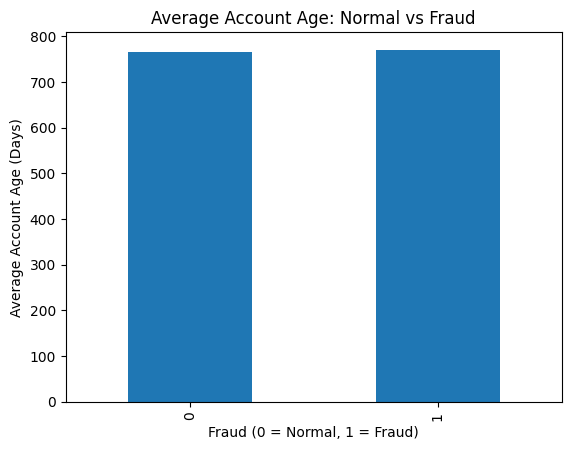

In [29]:
data.groupby("Fraud")["Account_Age_Days"].mean().plot(kind="bar")

plt.title("Average Account Age: Normal vs Fraud")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Account Age (Days)")
plt.show()

6. Fraud Signal Findings

The statistical analysis identified the following potential fraud signals:

- High transaction amount combined with high transaction frequency.
- Fraudulent transactions had a slightly higher average transaction amount.
- Fraudulent transactions showed a slightly higher average transaction frequency.
- 37 transactions were identified as suspicious based on high amount and high frequency.
- Among the 37 suspicious transactions, 6 were fraudulent.
- Device changes and account age did not show strong differences between normal and fraudulent transactions.

These signals can help in identifying transactions that require further monitoring.

7. Visual Analysis

Graphs and charts were used to understand the relationship between transaction features and fraud.

The visual analysis included:
- Normal vs Fraud Transactions
- Transaction Amount Distribution
- Average Transaction Amount by Fraud
- Average Transaction Frequency by Fraud
- Average Device Changes by Fraud
- Average Account Age by Fraud

These visualizations helped to identify differences and unusual patterns between normal and fraudulent transactions.


8. Business Recommendations

Based on the statistical analysis, the following recommendations are suggested:

- Monitor high-value and high-frequency transactions carefully.
- Use multiple fraud signals together instead of relying on transaction amount alone.
- Flag unusual transaction patterns for additional verification.
- Continuously monitor suspicious user activity.
- Use statistical analysis as an early warning system for possible fraud.

9. Future Scope

The project can be improved by using larger real-world UPI transaction datasets.

Future analysis can include machine learning models, real-time fraud detection, and advanced anomaly detection techniques.

10. Conclusion

Statistical analysis helped identify suspicious transaction patterns in the UPI dataset.

High transaction amount and high transaction frequency together can be useful fraud signals. Statistical methods can therefore support early identification and monitoring of potentially fraudulent transactions.